In [1]:
import json
import os 
import numpy as np
from pathlib import Path
from read_json import read_json
from turnmill_process import TurnmillProcess

test_dir = Path.cwd().parent.parent.resolve() / "testdata/Diameter16Z4endmill"
test_paths = os.listdir(test_dir)

break_list = []
processes = []

In [2]:
for file in test_paths:
    if file.endswith('.json'):
        data_dict = read_json(os.path.join(test_dir, file))
        process = TurnmillProcess(data_dict, nChannels=3)
        channel_data = np.array([data_dict[f"Channel_{i}"]["Signal"] for i in range(1, 4)])
        num_samples = channel_data.shape[1]
        dt = 1 / data_dict["File_Header"]["SampleFrequency"]  # time interval between samples
        break_list.append(data_dict["break"])

        for j in range(channel_data.shape[1]):
            process.add_datapoint(timestamp=dt*j, values=channel_data[:, j].tolist())

        processes.append(process)

In [3]:
print(f"Number of breaks: {sum(break_list)}/{len(break_list)}")

Number of breaks: 39/71


AttributeError: 'TurnmillProcess' object has no attribute 'get_timestamps'

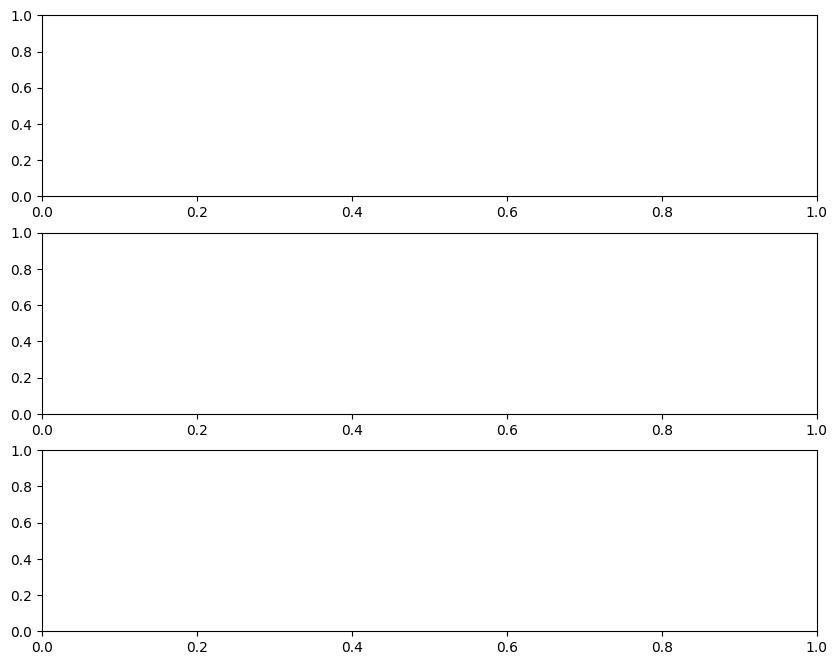

In [4]:
import matplotlib.pyplot as plt

for i in range(6):
    #make 3 subplots for x, y, z acceleration
    fig, ax = plt.subplots(3, 1, figsize=(10, 8))
    p = processes[i]
    time = p.get_timestamps()
    for ch in range(3):
        signal = p.get_channel_array(ch)
        ax[ch].plot(time, signal)
        ax[ch].set_title(f'Channel {ch+1} Signal')
        ax[ch].set_ylabel('Signal Amplitude')
        ax[ch].grid()

    ax[2].set_xlabel('Time (s)')

    plt.tight_layout()
    plt.show()
